# FIAP TECH CHALLENGE 1 - GRUPO SSP

## 5. MODELO PREDITIVO - K-NEAREST NEIGHBORS (KNN)

KNN é um algoritmo de classificação baseado em instâncias que classifica novos casos baseando-se na classe dos k vizinhos mais próximos no espaço de features.

In [48]:
from pathlib import Path

BASE_PATH = Path.cwd().resolve().parent.parent
print(f"Base path: {BASE_PATH.absolute()}")

Base path: /Users/matias/Projetos/fiap/tech-challenge-1


In [49]:
import pandas as pd
import numpy as np

df = pd.read_parquet(BASE_PATH / "data" / "processed" / "df_preprocessed.parquet")

print(f"Shape do dataset: {df.shape}")
print(f"\nColunas: {df.columns.tolist()}")

Shape do dataset: (57022, 38)

Colunas: ['AG_AMEACA', 'AG_CORTE', 'AG_ENFOR', 'AG_ENVEN', 'AG_FOGO', 'AG_FORCA', 'AG_OBJETO', 'AG_OUTROS', 'AG_QUENTE', 'AUTOR_ALCO', 'AUTOR_SEXO', 'CICL_VID', 'CS_RACA', 'DEF_TRANS', 'IDENT_GEN', 'ORIENT_SEX', 'OUT_VEZES', 'SG_UF', 'SIT_CONJUG', 'VIOL_FINAN', 'VIOL_FISIC', 'VIOL_INFAN', 'VIOL_LEGAL', 'VIOL_NEGLI', 'VIOL_OUTR', 'VIOL_PSICO', 'VIOL_SEXU', 'VIOL_TORT', 'VIOL_TRAF', 'DIA_SEMANA_OCOR', 'MES_OCOR', 'REL_PARCEIRO_INTIMO', 'REL_FAMILIAR', 'REL_CONHECIDO', 'REL_INSTITUCIONAL', 'REL_OUTROS_FLAG', 'ESCOLARIDADE', 'CIRC_LESAO_FAMILIA']


Distribuição da variável target (OUT_VEZES):
OUT_VEZES
1.0    30277
0.0    26745
Name: count, dtype: int64

Proporção:
OUT_VEZES
1.0    0.530971
0.0    0.469029
Name: proportion, dtype: float64


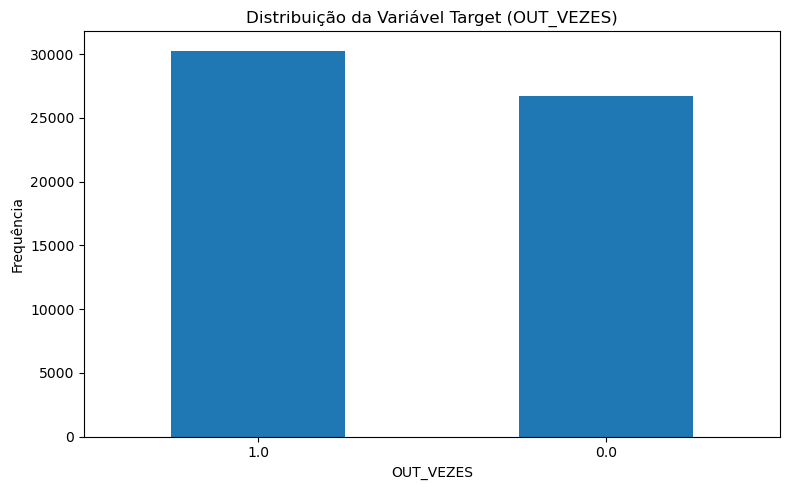

In [50]:
print("Distribuição da variável target (OUT_VEZES):")
print(df['OUT_VEZES'].value_counts())
print(f"\nProporção:")
print(df['OUT_VEZES'].value_counts(normalize=True))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
df['OUT_VEZES'].value_counts().plot(kind='bar')
plt.title('Distribuição da Variável Target (OUT_VEZES)')
plt.xlabel('OUT_VEZES')
plt.ylabel('Frequência')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
from sklearn.preprocessing import LabelEncoder

df_clean = df.dropna(subset=['OUT_VEZES']).copy()

X = df_clean.drop(columns=['OUT_VEZES']).copy()
y = df_clean['OUT_VEZES'].copy()

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nColunas de features: {X.columns.tolist()}")

label_encoders = {}
X_encoded = X.copy()

print("\nAplicando LabelEncoder em todas as features categóricas...")
for col in X.columns:
    col_data = X_encoded[col].astype(str)
    
    if col_data.str.contains('nan', case=False, na=False).any():
        mode_value = col_data[col_data != 'nan'].mode()[0] if len(col_data[col_data != 'nan'].mode()) > 0 else '0'
        col_data = col_data.replace('nan', mode_value)
    
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(col_data)
    label_encoders[col] = le
    
    print(f"  {col}: {len(le.classes_)} categorias únicas")

print("\nVerificando valores faltantes...")
missing_count = X_encoded.isna().sum().sum()
if missing_count > 0:
    print(f"  Encontrados {missing_count} valores faltantes")
    for col in X_encoded.columns:
        mode_value = X_encoded[col].mode()[0] if len(X_encoded[col].mode()) > 0 else 0
        X_encoded[col] = X_encoded[col].fillna(mode_value)
    print("  Valores faltantes tratados")
else:
    print("  Nenhum valor faltante encontrado")

print("\nEncoding da variável target...")
if y.dtype == 'object':
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y.astype(str))
    print(f"  Classes originais: {le_target.classes_}")
    print(f"  Classes codificadas: {np.unique(y_encoded)}")
    y = y_encoded
else:
    print(f"  Target já é numérica: {np.unique(y)}")

print(f"\nDataset preparado:")
print(f"  Features (X_encoded): {X_encoded.shape}")
print(f"  Target (y): {y.shape}")
print(f"  Tipo de dados: {X_encoded.dtypes.unique()}")

Features (X): (57022, 37)
Target (y): (57022,)

Colunas de features: ['AG_AMEACA', 'AG_CORTE', 'AG_ENFOR', 'AG_ENVEN', 'AG_FOGO', 'AG_FORCA', 'AG_OBJETO', 'AG_OUTROS', 'AG_QUENTE', 'AUTOR_ALCO', 'AUTOR_SEXO', 'CICL_VID', 'CS_RACA', 'DEF_TRANS', 'IDENT_GEN', 'ORIENT_SEX', 'SG_UF', 'SIT_CONJUG', 'VIOL_FINAN', 'VIOL_FISIC', 'VIOL_INFAN', 'VIOL_LEGAL', 'VIOL_NEGLI', 'VIOL_OUTR', 'VIOL_PSICO', 'VIOL_SEXU', 'VIOL_TORT', 'VIOL_TRAF', 'DIA_SEMANA_OCOR', 'MES_OCOR', 'REL_PARCEIRO_INTIMO', 'REL_FAMILIAR', 'REL_CONHECIDO', 'REL_INSTITUCIONAL', 'REL_OUTROS_FLAG', 'ESCOLARIDADE', 'CIRC_LESAO_FAMILIA']

Aplicando LabelEncoder em todas as features categóricas...
  AG_AMEACA: 2 categorias únicas
  AG_CORTE: 2 categorias únicas
  AG_ENFOR: 2 categorias únicas
  AG_ENVEN: 2 categorias únicas
  AG_FOGO: 2 categorias únicas
  AG_FORCA: 2 categorias únicas
  AG_OBJETO: 2 categorias únicas
  AG_OUTROS: 2 categorias únicas
  AG_QUENTE: 2 categorias únicas
  AUTOR_ALCO: 2 categorias únicas
  AUTOR_SEXO: 4 cat

DIVISÃO DOS DADOS:
  Treino: 39915 amostras (70.0%)
  Teste: 17107 amostras (30.0%)

Distribuição da target no conjunto de TREINO:
  Classe 0.0: 0.4690 (46.90%)
  Classe 1.0: 0.5310 (53.10%)

Distribuição da target no conjunto de TESTE:
  Classe 0.0: 0.4690 (46.90%)
  Classe 1.0: 0.5310 (53.10%)


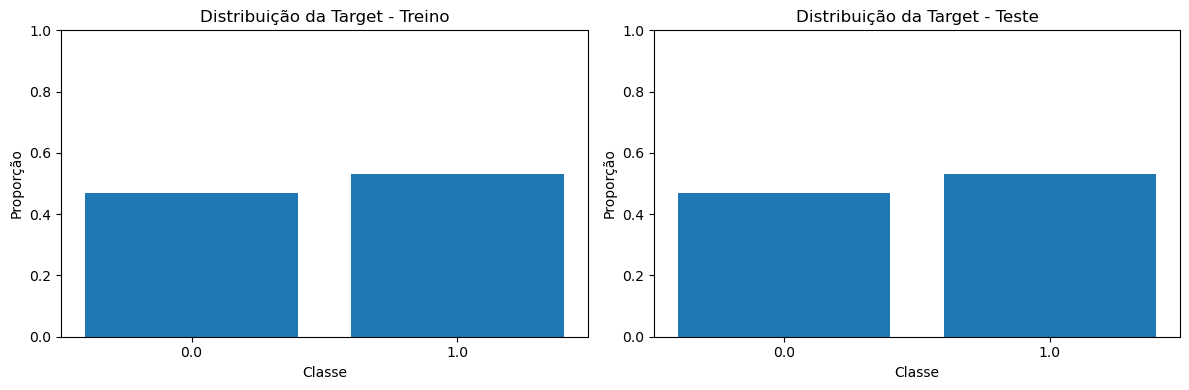

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print("DIVISÃO DOS DADOS:")
print(f"  Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"  Teste: {X_test.shape[0]} amostras ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"\nDistribuição da target no conjunto de TREINO:")
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
for classe, prop in train_dist.items():
    print(f"  Classe {classe}: {prop:.4f} ({prop*100:.2f}%)")

print(f"\nDistribuição da target no conjunto de TESTE:")
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
for classe, prop in test_dist.items():
    print(f"  Classe {classe}: {prop:.4f} ({prop*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(train_dist.index.astype(str), train_dist.values)
axes[0].set_title('Distribuição da Target - Treino')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Proporção')
axes[0].set_ylim([0, 1])

axes[1].bar(test_dist.index.astype(str), test_dist.values)
axes[1].set_title('Distribuição da Target - Teste')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Proporção')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [53]:
print("Verificando qualidade dos dados...")

print(f"  Valores infinitos em X_train: {np.isinf(X_train.values).sum()}")
print(f"  Valores infinitos em X_test: {np.isinf(X_test.values).sum()}")

variances = X_train.var()
zero_var_cols = variances[variances == 0].index.tolist()
if zero_var_cols:
    print(f"  Colunas com variância zero: {zero_var_cols}")
    X_train = X_train.drop(columns=zero_var_cols)
    X_test = X_test.drop(columns=zero_var_cols)
    print(f"  Colunas removidas. Novo shape: {X_train.shape}")

Verificando qualidade dos dados...
  Valores infinitos em X_train: 0
  Valores infinitos em X_test: 0


In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

print("Normalizando os dados...")
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Dados normalizados!")
print(f"  Média das features (treino): {X_train_scaled.mean(axis=0).abs().max():.6f}")
print(f"  Desvio padrão (treino): {X_train_scaled.std(axis=0).min():.6f}")

print("\nTreinando modelo KNN...")
print("=" * 60)

model = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    algorithm='auto',
    metric='minkowski',
    p=2,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

print("Modelo treinado com sucesso!")
print(f"\nInformações do modelo:")
print(f"  Número de neighbors: {model.n_neighbors}")
print(f"  Número de features: {model.n_features_in_}")
print(f"  Número de classes: {len(model.classes_)}")
print(f"  Classes: {model.classes_}")

Normalizando os dados...
Dados normalizados!
  Média das features (treino): 0.000000
  Desvio padrão (treino): 1.000013

Treinando modelo KNN...
Modelo treinado com sucesso!

Informações do modelo:
  Número de neighbors: 5
  Número de features: 37
  Número de classes: 2
  Classes: [0. 1.]


Fazendo predições...
Predições concluídas!

MÉTRICAS DO MODELO

Métricas Gerais:
  Acurácia:  0.6733 (67.33%)
  Precisão:  0.6728 (67.28%)
  Recall:    0.6733 (67.33%)
  F1-Score:  0.6728 (67.28%)
  ROC-AUC:   0.7173 (71.73%)

Métricas por Classe:
              precision    recall  f1-score   support

    Classe 0       0.66      0.63      0.64      8024
    Classe 1       0.69      0.71      0.70      9083

    accuracy                           0.67     17107
   macro avg       0.67      0.67      0.67     17107
weighted avg       0.67      0.67      0.67     17107


MATRIZ DE CONFUSÃO

                Pred: Classe 0  Pred: Classe 1
Real: Classe 0            5066            2958
Real: Classe 1            2631            6452

  Verdadeiros Negativos (TN): 5066
  Falsos Positivos (FP):      2958
  Falsos Negativos (FN):      2631
  Verdadeiros Positivos (TP): 6452


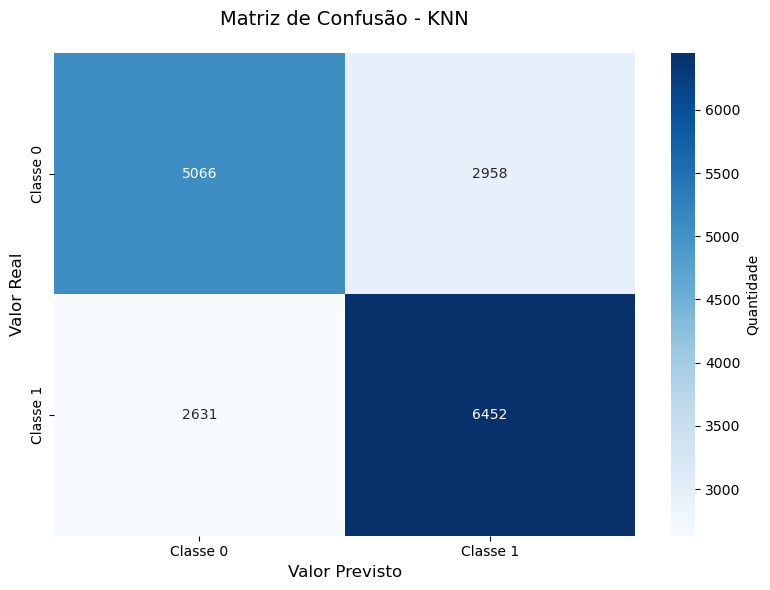

In [55]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

print("Fazendo predições...")
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Predições concluídas!\n")

print("=" * 60)
print("MÉTRICAS DO MODELO")
print("=" * 60)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"\nMétricas Gerais:")
print(f"  Acurácia:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precisão:  {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

if len(np.unique(y_test)) == 2:
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        print(f"  ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)")
    except Exception as e:
        print(f"  ROC-AUC:   Não foi possível calcular ({e})")

print(f"\nMétricas por Classe:")
print(classification_report(y_test, y_pred, target_names=['Classe 0', 'Classe 1']))

print("\n" + "=" * 60)
print("MATRIZ DE CONFUSÃO")
print("=" * 60)
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Real: Classe 0', 'Real: Classe 1'],
    columns=['Pred: Classe 0', 'Pred: Classe 1']
)

print("\n" + cm_df.to_string())
print(f"\n  Verdadeiros Negativos (TN): {cm[0, 0]}")
print(f"  Falsos Positivos (FP):      {cm[0, 1]}")
print(f"  Falsos Negativos (FN):      {cm[1, 0]}")
print(f"  Verdadeiros Positivos (TP): {cm[1, 1]}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Classe 0', 'Classe 1'],
            yticklabels=['Classe 0', 'Classe 1'],
            cbar_kws={'label': 'Quantidade'})
plt.title('Matriz de Confusão - KNN', fontsize=14, pad=20)
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Previsto', fontsize=12)
plt.tight_layout()
plt.show()

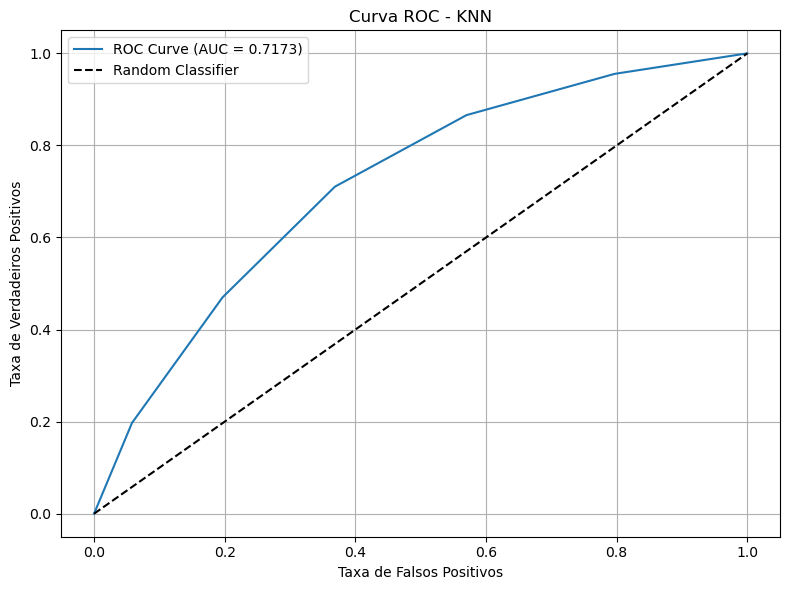

In [56]:
if len(np.unique(y_test)) == 2:
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title('Curva ROC - KNN')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 5.1. Otimização do hiperparâmetro k

Testando diferentes valores de k para encontrar o melhor desempenho.

Testando diferentes valores de k...
  k=1: Acurácia média = 0.6293 (+/- 0.0090)
  k=3: Acurácia média = 0.6616 (+/- 0.0070)
  k=5: Acurácia média = 0.6769 (+/- 0.0100)
  k=7: Acurácia média = 0.6835 (+/- 0.0119)
  k=9: Acurácia média = 0.6901 (+/- 0.0079)
  k=11: Acurácia média = 0.6915 (+/- 0.0064)
  k=13: Acurácia média = 0.6947 (+/- 0.0065)
  k=15: Acurácia média = 0.6967 (+/- 0.0072)
  k=17: Acurácia média = 0.6993 (+/- 0.0043)
  k=19: Acurácia média = 0.7011 (+/- 0.0044)
  k=21: Acurácia média = 0.7012 (+/- 0.0066)
  k=23: Acurácia média = 0.7022 (+/- 0.0056)
  k=25: Acurácia média = 0.7016 (+/- 0.0090)
  k=27: Acurácia média = 0.7018 (+/- 0.0073)
  k=29: Acurácia média = 0.7022 (+/- 0.0067)

Melhor k: 23 com acurácia de 0.7022


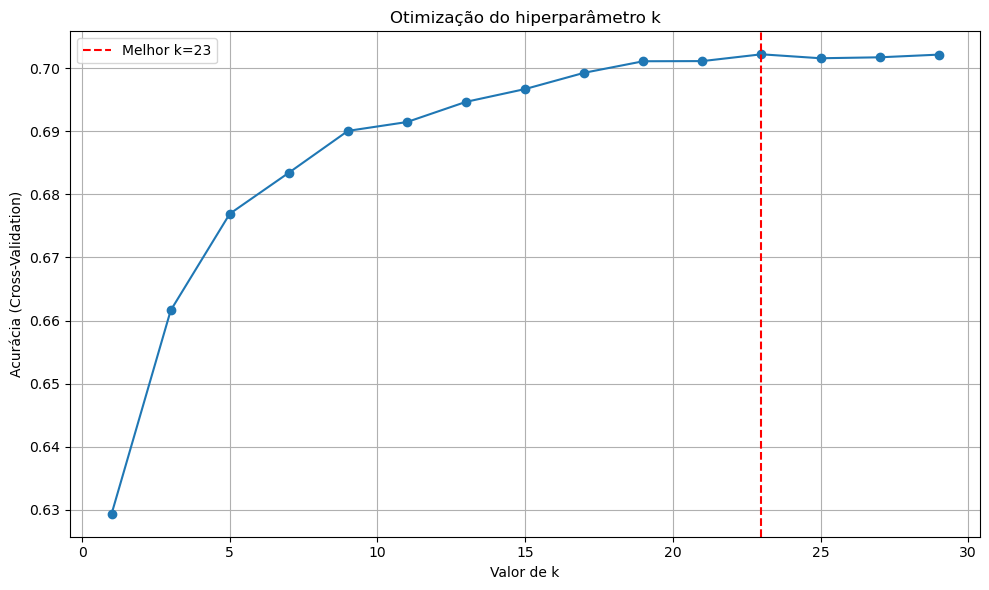

In [57]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 31, 2)
cv_scores = []

print("Testando diferentes valores de k...")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"  k={k}: Acurácia média = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

best_k = k_values[np.argmax(cv_scores)]
print(f"\nMelhor k: {best_k} com acurácia de {max(cv_scores):.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Melhor k={best_k}')
plt.xlabel('Valor de k')
plt.ylabel('Acurácia (Cross-Validation)')
plt.title('Otimização do hiperparâmetro k')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [58]:
print("Treinando modelo KNN com melhor k...")
print("=" * 60)

model_optimized = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='uniform',
    algorithm='auto',
    metric='minkowski',
    p=2,
    n_jobs=-1
)

model_optimized.fit(X_train_scaled, y_train)

y_pred_opt = model_optimized.predict(X_test_scaled)
y_pred_proba_opt = model_optimized.predict_proba(X_test_scaled)[:, 1]

accuracy_opt = accuracy_score(y_test, y_pred_opt)
precision_opt = precision_score(y_test, y_pred_opt, average='weighted', zero_division=0)
recall_opt = recall_score(y_test, y_pred_opt, average='weighted', zero_division=0)
f1_opt = f1_score(y_test, y_pred_opt, average='weighted', zero_division=0)

print("MÉTRICAS DO MODELO OTIMIZADO:")
print(f"  Acurácia:  {accuracy_opt:.4f} ({accuracy_opt*100:.2f}%)")
print(f"  Precisão:  {precision_opt:.4f} ({precision_opt*100:.2f}%)")
print(f"  Recall:    {recall_opt:.4f} ({recall_opt*100:.2f}%)")
print(f"  F1-Score:  {f1_opt:.4f} ({f1_opt*100:.2f}%)")

if len(np.unique(y_test)) == 2:
    try:
        roc_auc_opt = roc_auc_score(y_test, y_pred_proba_opt)
        print(f"  ROC-AUC:   {roc_auc_opt:.4f} ({roc_auc_opt*100:.2f}%)")
    except:
        pass

Treinando modelo KNN com melhor k...
MÉTRICAS DO MODELO OTIMIZADO:
  Acurácia:  0.6981 (69.81%)
  Precisão:  0.6986 (69.86%)
  Recall:    0.6981 (69.81%)
  F1-Score:  0.6960 (69.60%)
  ROC-AUC:   0.7536 (75.36%)
